### Preamble

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
import os

In [2]:
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"] # path to LaTeX installation
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.latex.preamble": r"\usepackage{amsmath}"})

In [3]:
# Solenoid length [mm] for visualization:
sollength = 100

# Directory with fieldmaps:
outdir = 'g4bl-output/'

# Figure directory:
figdir = 'figures/'

In [4]:
def readFieldMapData(file):
    ''' Returns a DataFrame with positions, time, and magnetic field components. From the fieldntuple G4bl command.
    The default units are mm for position and Tesla for B field.
    Inputs:
    file = G4beamline output file from fieldntuple (ascii) '''
    data = np.loadtxt(outdir+file)
    columns = ['x', 'y', 'z', 't', 'Bx', 'By', 'Bz']
    df = pd.DataFrame(data[:, 0:7], columns=columns)
    theta = np.arctan2(df['y'], df['x'])
    df['Br'] = df['Bx']*np.cos(theta) + df['By']*np.sin(theta)
    return df

In [5]:
def plot(data, file):

    unique_z = np.sort(data['z'].unique())
    init_data = data[data['z'] == unique_z[0]]
    x_unique = np.sort(init_data['x'].unique())
    y_unique = np.sort(init_data['y'].unique())
    X, Y = np.meshgrid(x_unique, y_unique)

    Br_init = init_data.pivot_table(index='y', columns='x', values='Br').values

    fig, axs = plt.subplots(1, 2, figsize=(20,10), width_ratios=[1,4])
    ax, ax2 = axs[1], axs[0]

    arrayy = [0, 0]
    ax2.set_xlim(-400, 400)
    ax2.axvspan(xmin=-sollength/2, xmax=sollength/2, color='gray', alpha=0.2)
    ax2.set_yticks([])
    ax2.set_xticks([])
    ax2.set_frame_on(False)
    vline = ax2.axvline(x=unique_z[0], color='black')

    ax.set_xlabel('$x$ [mm]')
    ax.set_ylabel('$y$ [mm]')
    cmap = sns.color_palette("mako", as_cmap=True)
    pcm = ax.pcolormesh(X, Y, Br_init, cmap=cmap, shading='auto', vmin=data['Br'].min(), vmax=data['Br'].max())
    cbar = plt.colorbar(pcm, ax=ax, label='$B_r$ [T]')
    ax.set_aspect('equal')

    quiver_plot = None

    def animate(frame):

        nonlocal quiver_plot

        z_val = unique_z[frame]
        vline.set_xdata([z_val])

        data_slice = data[data['z'] == z_val]
        Bx_grid = data_slice.pivot_table(index='y', columns='x', values='Bx').values
        By_grid = data_slice.pivot_table(index='y', columns='x', values='By').values
        Br_grid = data_slice.pivot_table(index='y', columns='x', values='Br').values

        step = 5
        X_ds = X[::step, ::step]
        Y_ds = Y[::step, ::step]
        Bx_ds = Bx_grid[::step, ::step]
        By_ds = By_grid[::step, ::step]

        magnitude = np.sqrt(Bx_ds**2 + By_ds**2)
        Bx_norm = Bx_ds / (magnitude + 1e-12)
        By_norm = By_ds / (magnitude + 1e-12)

        pcm.set_array(Br_grid.ravel())

        if quiver_plot:
            quiver_plot.remove()

        quiver_plot = ax.quiver(X_ds, Y_ds, Bx_norm, By_norm, color='white', scale=50, width=0.002, zorder=10)

        return [pcm, vline, quiver_plot]


    animation = FuncAnimation(fig, animate, frames=len(unique_z), interval=200, blit=False, repeat=False)
    animation.save(figdir+file, writer='pillow')

### No tilts

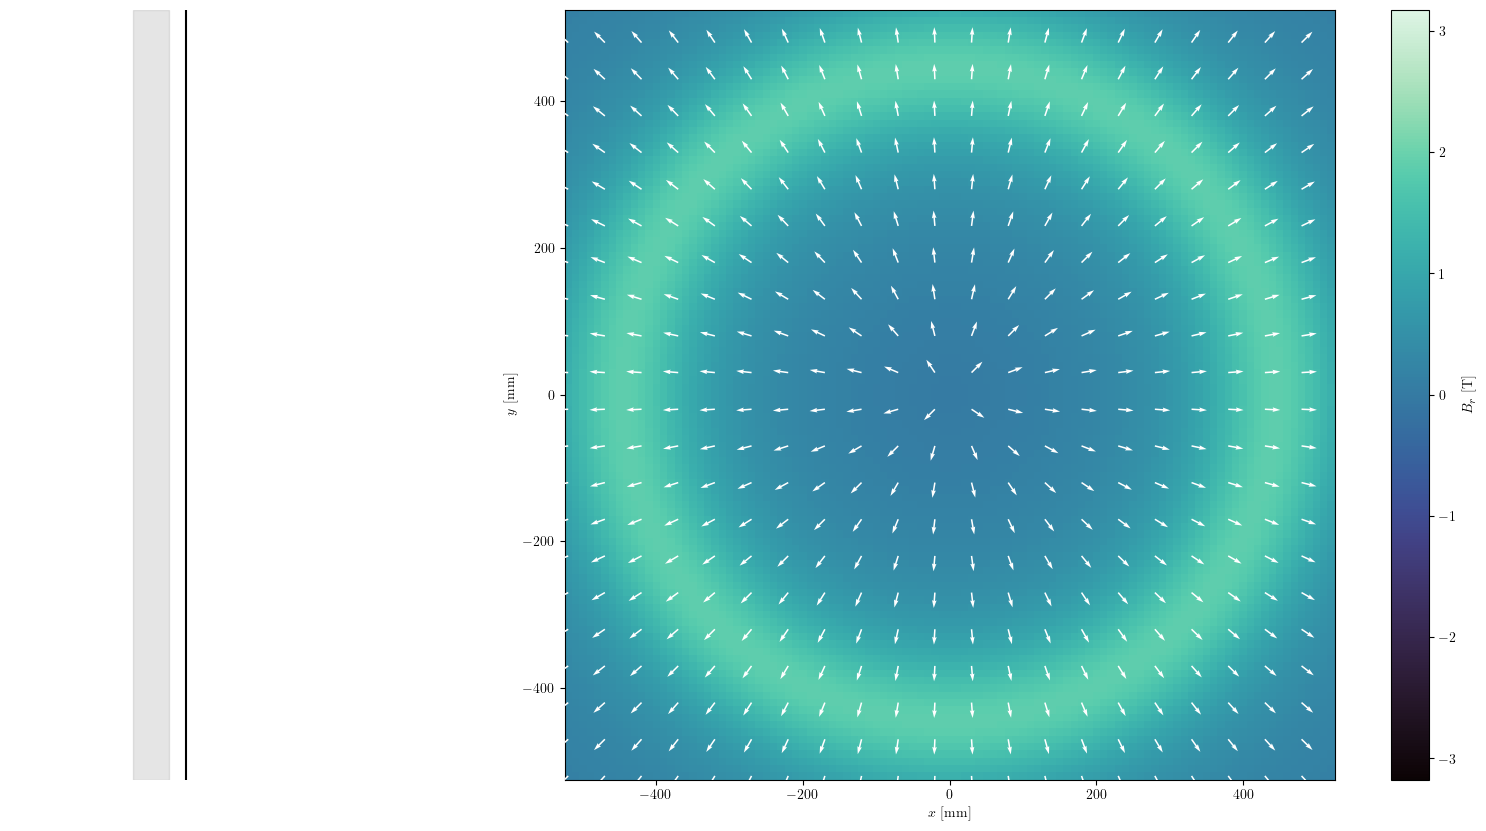

In [6]:
data = readFieldMapData('fieldmap_notilts.txt')

plot(data, 'Br_notilts.gif')

### With pitch

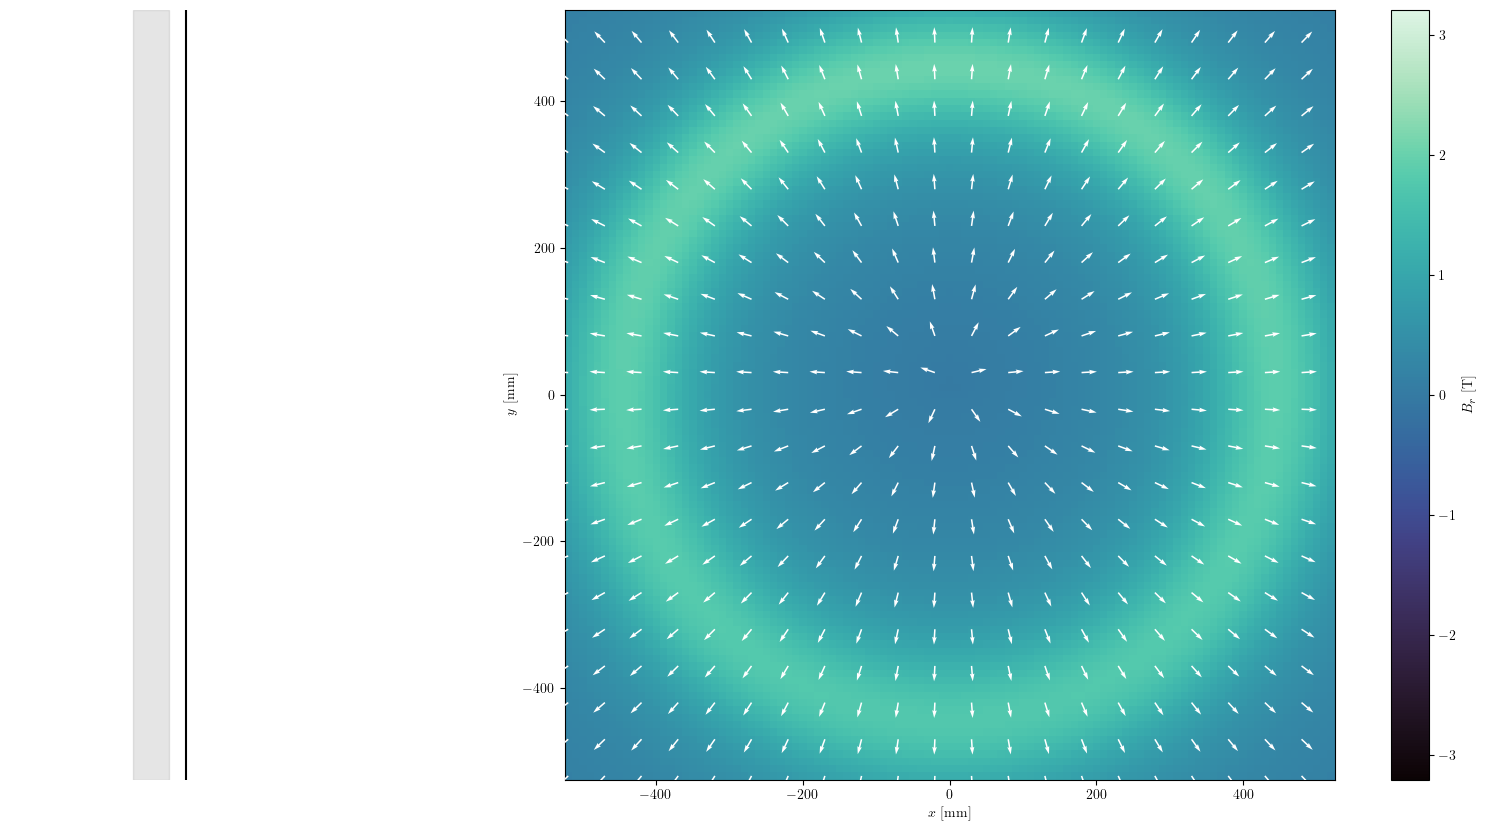

In [7]:
data = readFieldMapData('fieldmap_pitch1.txt') # 1 degree tilt along x-axis

plot(data, 'Br_pitch1.gif')

### With pitch and roll

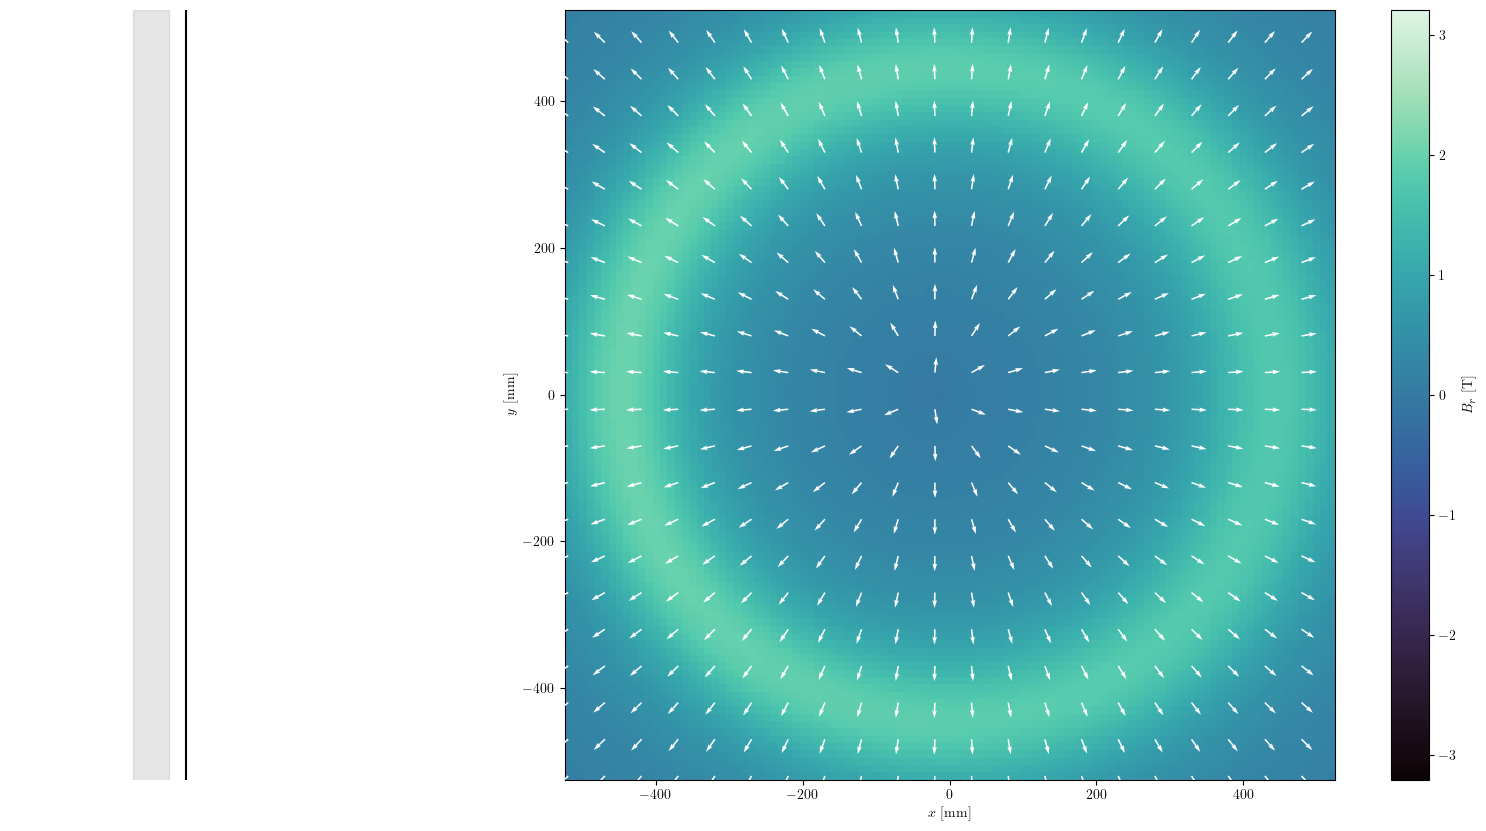

In [8]:
data = readFieldMapData('fieldmap_pitch1_roll90.txt') # 1 degree tilt along x-axis, then 90 degree tilt along z-axis

plot(data, 'Br_pitch1_roll90.gif')